In [1]:
import pandas as pd

# Load behavioural + RW output
csv_path = "participant_P001_session_1_RW_trialoutcome_singlealpha.csv"
behav = pd.read_csv(csv_path)

# Keep only trial rows if there are other markers
behav = behav[behav["trial_type"] == "trial"].reset_index(drop=True)

# Extract predictors: expected value and prediction error (shape: n_trials,)
V_RW = behav["V_RW"].values        # expected value
PE_RW = behav["PE_RW"].values      # prediction error
trials = behav["trial"].values



In [41]:
import mne

epochs = mne.read_epochs("/Users/arthurhsia/Desktop/Psychology/EEG/data/derivatives/mne_preproc/sub-01/ses-01/sub-01_ses-01_task-Cannonball_MF_epochs_feedback_clean_alpha-epo.fif", preload=True)
# Make sure these epochs are already trial‑aligned with your RW CSV
print(epochs)


Reading /Users/arthurhsia/Desktop/Psychology/EEG/data/derivatives/mne_preproc/sub-01/ses-01/sub-01_ses-01_task-Cannonball_MF_epochs_feedback_clean_alpha-epo.fif ...
    Found the data of interest:
        t =    -199.22 ...     800.78 ms
        0 CTF compensation matrices available
Not setting metadata
715 matching events found
No baseline correction applied
0 projection items activated
<EpochsFIF | 715 events (all good), -0.199 – 0.801 s (baseline -0.2 – 0 s), ~95.4 MiB, data loaded,
 'loss': 261
 'reward': 454>


In [42]:
from mne.time_frequency import tfr_morlet
import numpy as np

# ------------- Time-frequency decomposition -------------
epochs_pick = epochs.copy()

freqs = np.linspace(8, 12, 5)      # alpha band
n_cycles = freqs / 2.0

power = tfr_morlet(
    epochs_pick, freqs=freqs, n_cycles=n_cycles,
    use_fft=True, return_itc=False, average=False
)
# power.data shape: (n_trials, n_channels, n_freqs, n_times)

posterior = ['Oz', 'P1', 'PO3', 'PO7', 'PO8', 'O1', 'O2']
posterior = [ch for ch in posterior if ch in power.ch_names]
idx_post = [power.ch_names.index(ch) for ch in posterior]
print("Posterior channels used:", posterior)

# Define your feedback window (adapt as needed)
tmin, tmax = 0.00, 1
time_mask = (power.times >= tmin) & (power.times <= tmax)

# Average over alpha freqs, then time, then posterior sensors
alpha_single = power.data.mean(axis=2)[:, :, time_mask].mean(axis=2)      # (trials, channels)
alpha_post = alpha_single[:, idx_post].mean(axis=1)                       # (trials,)

NOTE: tfr_morlet() is a legacy function. New code should use .compute_tfr(method="morlet").
Posterior channels used: ['Oz', 'P1', 'PO3', 'PO7', 'PO8', 'O1', 'O2']


In [43]:
# Make sure no negatives/zeros if you plan log-transform; otherwise simple scaling:
alpha_post_norm = alpha_post / np.max(alpha_post)
# or z-score:
# alpha_post_norm = (alpha_post - alpha_post.mean()) / alpha_post.std()


In [44]:
import numpy as np
from scipy.stats import pearsonr

def simulate_rw_alpha(outcome, alpha_lr, epsilon=0.0, V0=None):
    """
    Simulate a Rescorla-Wagner value trajectory V_t driven by outcome[t-1].
    outcome: array of 0/1, shape (n_trials,)
    alpha_lr: learning rate in [0,1]
    epsilon: constant bias term
    V0: initial value; if None, start at 0.
    Returns V_hat: shape (n_trials,)
    """
    n_trials = len(outcome)
    V_hat = np.zeros(n_trials)
    if V0 is None:
        V_hat[0] = 0.0
    else:
        V_hat[0] = V0

    for t in range(1, n_trials):
        lam = outcome[t-1]            # use previous trial outcome
        V_prev = V_hat[t-1]
        PE = lam - V_prev
        V_hat[t] = V_prev + alpha_lr * PE + epsilon
    return V_hat

def fit_rw_to_alpha(alpha_obs, outcome,
                    alphas=np.linspace(0.0, 1.0, 101),
                    epsilons=np.linspace(-0.1, 0.1, 41)):
    """
    Grid-search best (alpha_lr, epsilon) to make RW trajectory V_hat
    match observed alpha (least squares). Returns best parameters,
    corresponding V_hat, and correlation r.
    """
    alpha_obs = np.asarray(alpha_obs)
    outcome = np.asarray(outcome)
    assert alpha_obs.shape == outcome.shape

    best_mse = np.inf
    best_alpha = None
    best_eps = None
    best_V_hat = None

    for a in alphas:
        for e in epsilons:
            V_hat = simulate_rw_alpha(outcome, a, e, V0=alpha_obs[0])
            mse = np.mean((V_hat - alpha_obs) ** 2)
            if mse < best_mse:
                best_mse = mse
                best_alpha = a
                best_eps = e
                best_V_hat = V_hat

    r, _ = pearsonr(alpha_obs, best_V_hat)
    return best_alpha, best_eps, best_V_hat, r


Best learning rate α: 0.04
Best bias ε: -0.015
Correlation r(modelled V_hat, alpha): 0.0019065671040535458


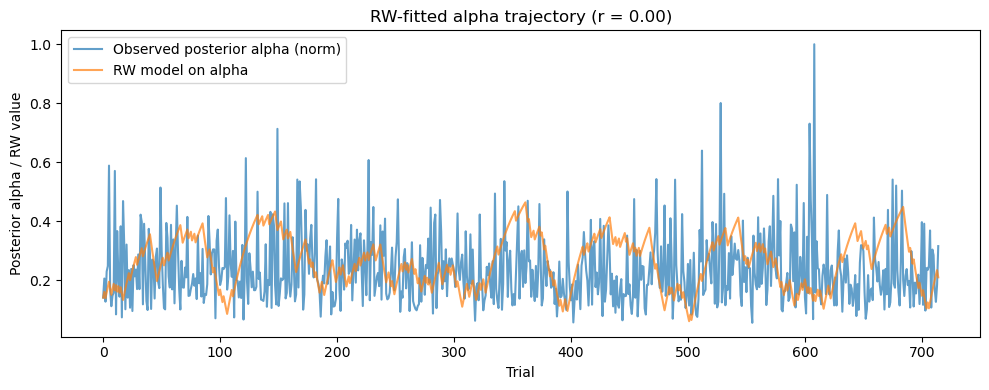

In [45]:
# alpha_post_norm: posterior alpha (norm) for chosen window, shape (n_trials,)
# build outcome from your behavioural CSV or events: 1=reward (asteroidTail, 19), 0=loss (ballExplode, 17)
# e.g., from CSV column trial_outcome: 1=reward, 0=loss
import pandas as pd

behav = pd.read_csv("participant_P001_session_1_RW_trialoutcome_singlealpha.csv")
behav = behav[behav["trial_type"] == "trial"].reset_index(drop=True)
outcome = behav["trial_outcome"].values[:len(alpha_post_norm)]  # ensure same length

best_alpha, best_eps, V_hat, r = fit_rw_to_alpha(alpha_post_norm, outcome)

print("Best learning rate α:", best_alpha)
print("Best bias ε:", best_eps)
print("Correlation r(modelled V_hat, alpha):", r)

# Plot observed vs modelled alpha
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))
plt.plot(alpha_post_norm, label="Observed posterior alpha (norm)", alpha=0.7)
plt.plot(V_hat, label="RW model on alpha", alpha=0.7)
plt.xlabel("Trial")
plt.ylabel("Posterior alpha / RW value")
plt.title("RW-fitted alpha trajectory (r = {:.2f})".format(r))
plt.legend()
plt.tight_layout()
plt.show()